# Sales Data Analysis
Week 1 — Python for Data Analysis

Dataset: `sales_sample_data.csv` (656 rows, same dataset used for the Excel dashboard)

## 1. Load and Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sales_sample_data.csv")
print(df.shape)
df.head()

(656, 11)


,OrderID,OrderDate,Product,Category,Region,SalesRep,CustomerType,Quantity,UnitPrice,DiscountPct,Revenue
0,10613,03-01-2025,USB-C Cable,Electronics,East,Vikram Shah,Retail,5,292.32,0,1461.60
1,10379,03-01-2025,Notebook Set,Stationery,South,Vikram Shah,Wholesale,1,200.54,20,200.54
2,10004,04-01-2025,Office Chair,Furniture,South,Karan Mehta,Wholesale,3,6354.64,0,19063.92
3,10591,05-01-2025,Webcam HD,Electronics,North,Karan Mehta,Wholesale,10,3408.15,15,34081.50
4,10497,07-01-2025,Whiteboard,Office,West,Ananya Rao,Wholesale,1,2411.09,10,2411.09


In [2]:
df.dtypes

OrderID           int64
OrderDate           str
Product             str
Category            str
Region              str
SalesRep            str
CustomerType        str
Quantity          int64
UnitPrice       float64
DiscountPct       int64
Revenue         float64
dtype: object

## 2. Clean the Data
Same issues you already fixed in Excel: duplicates, blank SalesRep values, zero-quantity rows.

In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Fill blank SalesRep with "Unknown" instead of guessing
df["SalesRep"] = df["SalesRep"].fillna("Unknown")

# Drop zero-quantity rows -- not real sales
df = df[df["Quantity"] > 0]

print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 646


## 3. Calculate KPIs

In [4]:
import numpy as np

df["NetRevenue"] = df["Revenue"] * (1 - df["DiscountPct"] / 100)

total_revenue = df["NetRevenue"].sum()
total_orders = len(df)
avg_order_value = df["NetRevenue"].mean()
revenue_std = np.std(df["NetRevenue"])  # NumPy: measures how spread out order values are

print(f"Total Revenue: Rs.{total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: Rs.{avg_order_value:,.2f}")
print(f"Revenue Std Dev: Rs.{revenue_std:,.2f}")

Total Revenue: Rs.6,464,779.65
Total Orders: 646
Average Order Value: Rs.10,007.40
Revenue Std Dev: Rs.17,491.62


## 4. Group and Summarize

In [5]:
revenue_by_region = df.groupby("Region")["NetRevenue"].sum().sort_values(ascending=False)
print(revenue_by_region)

Region
South    1.729681e+06
West     1.699395e+06
North    1.623761e+06
East     1.411942e+06
Name: NetRevenue, dtype: float64


In [6]:
# TODO: revenue by Category, sorted descending
revenue_by_category = df.groupby("Category")["NetRevenue"].sum().sort_values(ascending=False)
print(revenue_by_category)


Category
Furniture      4.232986e+06
Electronics    1.279394e+06
Office         9.246020e+05
Stationery     2.779689e+04
Name: NetRevenue, dtype: float64


In [7]:
# TODO: revenue by SalesRep, sorted descending
revenue_by_rep = df.groupby("SalesRep")["NetRevenue"].sum().sort_values(ascending=False)
print(revenue_by_rep)


SalesRep
Karan Mehta    1.377473e+06
Priya Nair     1.336119e+06
Sneha Iyer     1.045888e+06
Rohit Verma    9.581517e+05
Ananya Rao     9.536478e+05
Vikram Shah    7.277358e+05
Unknown        6.576327e+04
Name: NetRevenue, dtype: float64


## 5. Visualizations

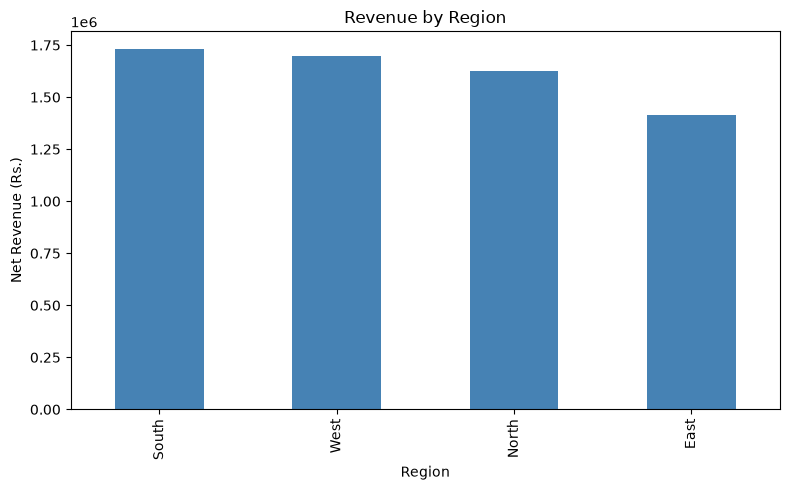

In [8]:
# TODO: bar chart of revenue by region
revenue_by_region.plot(kind="bar", title="Revenue by Region", figsize=(8,5), color="steelblue")
plt.ylabel("Net Revenue (Rs.)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()


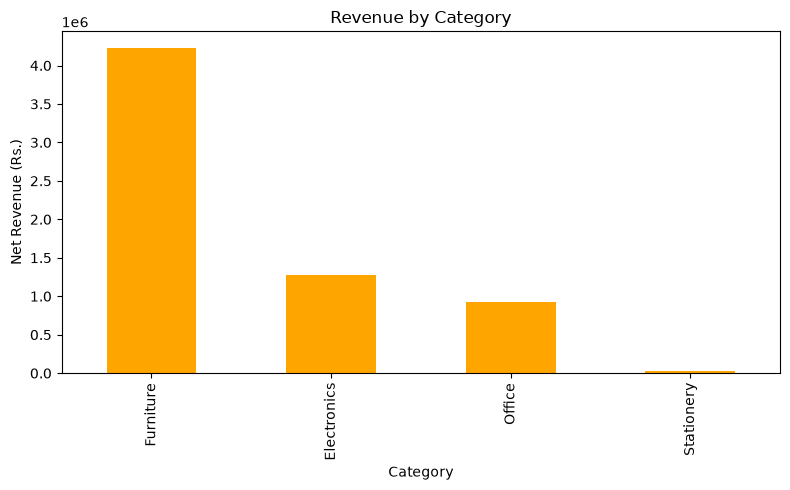

In [9]:
# TODO: bar chart of revenue by category

revenue_by_category.plot(kind="bar", title="Revenue by Category", figsize=(8,5), color="orange")
plt.ylabel("Net Revenue (Rs.)")
plt.xlabel("Category")
plt.tight_layout()
plt.show()

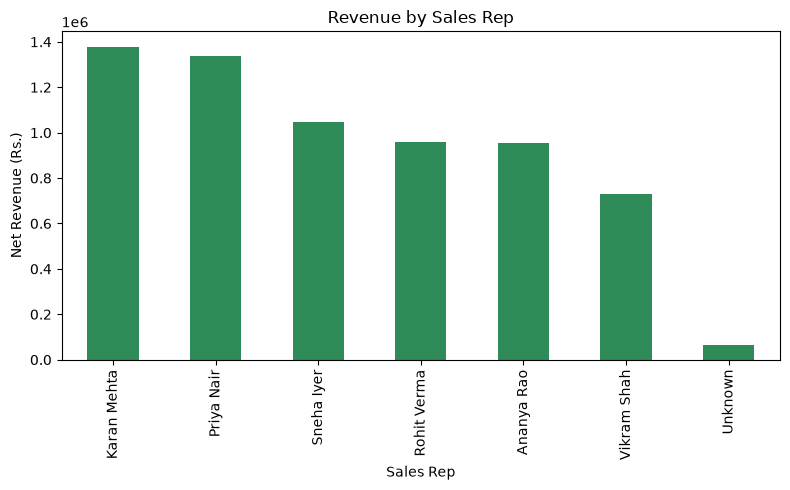

In [10]:
revenue_by_rep.plot(kind="bar", title="Revenue by Sales Rep", figsize=(8,5), color="seagreen")
plt.ylabel("Net Revenue (Rs.)")
plt.xlabel("Sales Rep")
plt.tight_layout()
plt.show()

In [11]:
 #Key Findings
The South region generated the highest net revenue at ₹17.3 lakh, narrowly ahead of West (₹17.0 lakh) and North (₹16.2 lakh), with East trailing at ₹14.1 lakh — regional performance is fairly balanced overall. By category, Furniture dominates sharply, accounting for ₹42.3 lakh of the ₹64.6 lakh total (roughly 65%), driven by high-ticket items like Standing Desks and Office Chairs, while Stationery contributes almost nothing (₹27.8K). Among sales reps, Karan Mehta and Priya Nair lead with over ₹13 lakh each, while 8 orders had no recorded sales rep and were grouped under "Unknown" (₹65.8K) — a data quality gap worth flagging to the business rather than quietly absorbing. Revenue per order varies widely (average ₹10,007, but a standard deviation of ₹17,492) — the spread makes sense given the mix of ₹199 notebook sets alongside ₹12,999 standing desks in the same dataset.

SyntaxError: invalid character '₹' (U+20B9) (4026077149.py, line 2)

In [ ]:
## 7. Data Validation

In [12]:
# Check DiscountPct is within a sane range (0-100)
invalid_discount = df[(df["DiscountPct"] < 0) | (df["DiscountPct"] > 100)]
print(f"Invalid discount values: {len(invalid_discount)}")

# Check Region only contains expected categories
print(df["Region"].unique())

# Check UnitPrice is always positive
invalid_price = df[df["UnitPrice"] <= 0]
print(f"Invalid unit prices: {len(invalid_price)}")

Invalid discount values: 0
<StringArray>
['East', 'South', 'North', 'West']
Length: 4, dtype: str
Invalid unit prices: 0


In [13]:
Q1 = df["NetRevenue"].quantile(0.25)
Q3 = df["NetRevenue"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["NetRevenue"] < lower_bound) | (df["NetRevenue"] > upper_bound)]
print(f"Outlier orders: {len(outliers)}")
print(f"Normal range: Rs.{lower_bound:,.2f} to Rs.{upper_bound:,.2f}")
outliers[["Product", "Quantity", "NetRevenue"]].sort_values("NetRevenue", ascending=False).head(10)

Outlier orders: 62
Normal range: Rs.-12,881.94 to Rs.25,753.81


,Product,Quantity,NetRevenue
256,Standing Desk,10,135050.000
606,Standing Desk,10,134830.600
99,Standing Desk,10,128169.100
288,Standing Desk,10,125986.400
456,Standing Desk,10,118829.040
161,Standing Desk,10,113294.610
203,Standing Desk,10,111051.055
229,Standing Desk,10,110058.680
308,Standing Desk,10,109156.560
365,Standing Desk,5,65980.150


In [14]:
correlation_matrix = df[["Quantity", "UnitPrice", "DiscountPct", "NetRevenue"]].corr()
print(correlation_matrix)

             Quantity  UnitPrice  DiscountPct  NetRevenue
Quantity     1.000000   0.032611    -0.019357    0.532027
UnitPrice    0.032611   1.000000    -0.045371    0.656941
DiscountPct -0.019357  -0.045371     1.000000   -0.041099
NetRevenue   0.532027   0.656941    -0.041099    1.000000


Month
2025-01    483624.4345
2025-02    547921.8175
2025-03    549084.9710
2025-04    347749.2790
2025-05    660457.0430
2025-06    558038.3840
2025-07    460399.1485
2025-08    572589.2685
2025-09    647778.2555
2025-10    425814.1540
2025-11    346411.0495
2025-12    864911.8500
Freq: M, Name: NetRevenue, dtype: float64


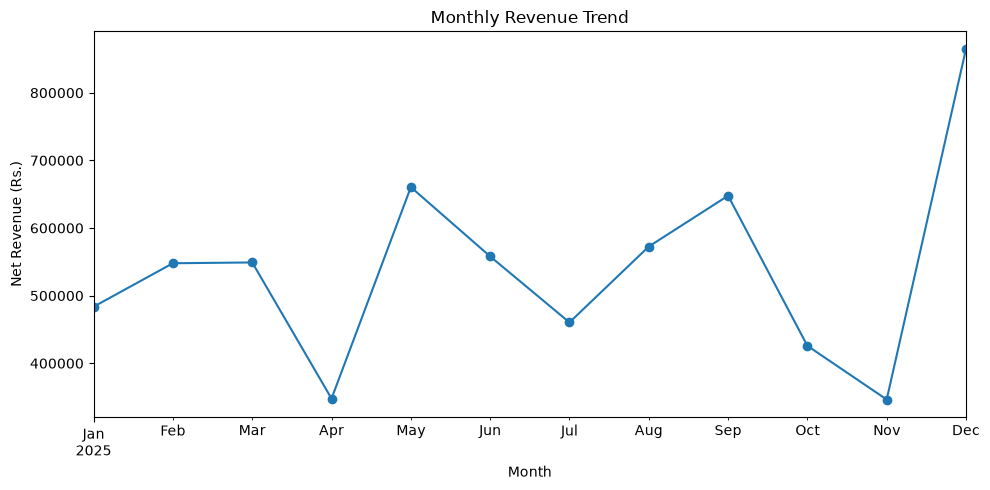

In [15]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"], format="%d-%m-%Y")
df["Month"] = df["OrderDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["NetRevenue"].sum()
print(monthly_revenue)

monthly_revenue.plot(kind="line", marker="o", title="Monthly Revenue Trend", figsize=(10,5))
plt.ylabel("Net Revenue (Rs.)")
plt.tight_layout()
plt.show()

In [16]:
print(df["NetRevenue"].describe())
print(f"\nMode of Region: {df['Region'].mode()[0]}")
print(f"Median NetRevenue: Rs.{df['NetRevenue'].median():,.2f}")

count       646.000000
mean      10007.398847
std       17505.171404
min         160.240000
25%        1606.469250
50%        3996.795000
75%       11265.406500
max      135050.000000
Name: NetRevenue, dtype: float64

Mode of Region: South
Median NetRevenue: Rs.3,996.80


In [17]:
df.to_csv("sales_data_cleaned_final.csv", index=False)
print("Saved cleaned dataset")

Saved cleaned dataset


In [18]:
# What fraction of orders came from each region?
region_probability = df["Region"].value_counts(normalize=True)
print(region_probability)

# What's the probability an order is BOTH from South AND Wholesale?
south_wholesale = df[(df["Region"] == "South") & (df["CustomerType"] == "Wholesale")]
prob_south_and_wholesale = len(south_wholesale) / len(df)
print(f"P(South AND Wholesale): {prob_south_and_wholesale:.3f}")

Region
South    0.263158
West     0.258514
North    0.246130
East     0.232198
Name: proportion, dtype: float64
P(South AND Wholesale): 0.096


In [20]:
from scipy import stats

x = df["Quantity"]
y = df["NetRevenue"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.3f}")

Slope: 3322.43
Intercept: -181.03
R-squared: 0.283
